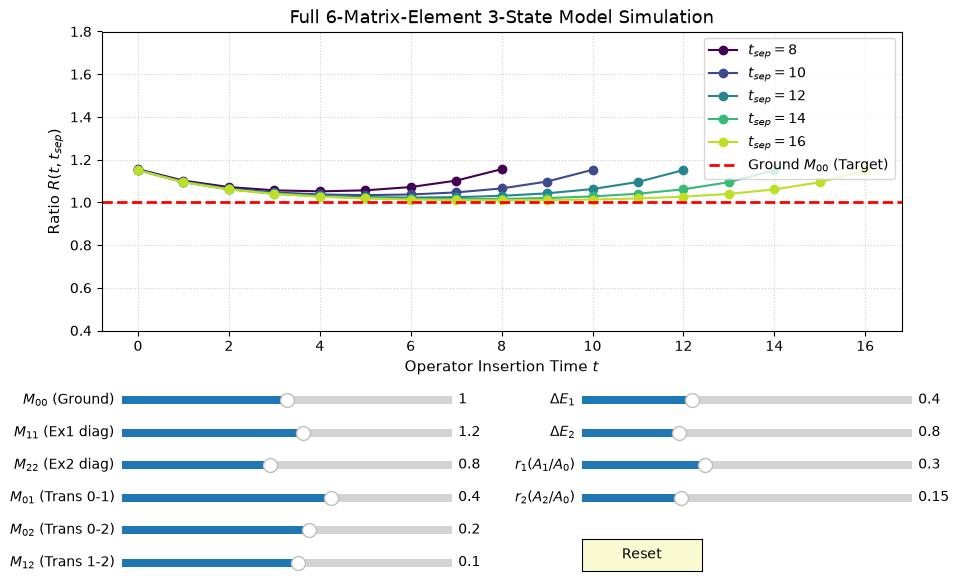

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button

# 1. 定义 3-State 比值计算模型
def compute_ratio(t_sep, dE1, dE2, r1, r2, M00, M11, M22, M01, M02, M12):
    t = np.arange(0, t_sep + 1)
    
    # 两点函数 C2pt
    c2pt = 1.0 + (r1**2) * np.exp(-dE1 * t_sep) + (r2**2) * np.exp(-dE2 * t_sep)
    
    # 三点函数 C3pt 的 6 个独立项 (假设 M_mn = M_nm)
    term00 = M00
    term11 = (r1**2) * M11 * np.exp(-dE1 * t_sep)
    term22 = (r2**2) * M22 * np.exp(-dE2 * t_sep)
    
    term01 = r1 * M01 * (np.exp(-dE1 * (t_sep - t)) + np.exp(-dE1 * t))
    term02 = r2 * M02 * (np.exp(-dE2 * (t_sep - t)) + np.exp(-dE2 * t))
    term12 = r1 * r2 * M12 * (np.exp(-dE1 * t) * np.exp(-dE2 * (t_sep - t)) + 
                              np.exp(-dE2 * t) * np.exp(-dE1 * (t_sep - t)))
    
    c3pt = term00 + term11 + term22 + term01 + term02 + term12
    return t, c3pt / c2pt

# 2. 初始化画布
fig, ax = plt.subplots(figsize=(10, 6.5))
plt.subplots_adjust(left=0.1, bottom=0.42)  # 留足下方放滑块的空间

t_sep_list = [8, 10, 12, 14, 16]
colors = plt.cm.viridis(np.linspace(0, 0.9, len(t_sep_list)))

# 默认初始参数
init_M00, init_M11, init_M22 = 1.0, 1.2, 0.8
init_M01, init_M02, init_M12 = 0.4, 0.2, 0.1
init_dE1, init_dE2 = 0.4, 0.8
init_r1,  init_r2  = 0.3, 0.15

# 绘制初态曲线
lines = []
for idx, t_sep in enumerate(t_sep_list):
    t, ratio = compute_ratio(t_sep, init_dE1, init_dE2, init_r1, init_r2, 
                             init_M00, init_M11, init_M22, init_M01, init_M02, init_M12)
    line, = ax.plot(t, ratio, 'o-', color=colors[idx], label=f'$t_{{sep}} = {t_sep}$')
    lines.append(line)

# 基态物理真值红线
target_line = ax.axhline(init_M00, color='red', linestyle='--', linewidth=2, label='Ground $M_{00}$ (Target)')

ax.set_xlabel('Operator Insertion Time $t$', fontsize=11)
ax.set_ylabel('Ratio $R(t, t_{sep})$', fontsize=11)
ax.set_title('Full 6-Matrix-Element 3-State Model Simulation', fontsize=13)
ax.legend(loc='upper right')
ax.grid(True, linestyle=':', alpha=0.6)
ax.set_ylim(0.4, 1.8)

# 3. 创建 10 个独立滑块 (Left col: 矩阵元 M_mn | Right col: 能量 gap & 重叠因子)
axcolor = 'lightgoldenrodyellow'

# 左列：6 个矩阵元滑块
ax_M00 = plt.axes([0.12, 0.30, 0.33, 0.025], facecolor=axcolor)
ax_M11 = plt.axes([0.12, 0.25, 0.33, 0.025], facecolor=axcolor)
ax_M22 = plt.axes([0.12, 0.20, 0.33, 0.025], facecolor=axcolor)
ax_M01 = plt.axes([0.12, 0.15, 0.33, 0.025], facecolor=axcolor)
ax_M02 = plt.axes([0.12, 0.10, 0.33, 0.025], facecolor=axcolor)
ax_M12 = plt.axes([0.12, 0.05, 0.33, 0.025], facecolor=axcolor)

# 右列：4 个能隙与重叠因子滑块
ax_dE1 = plt.axes([0.58, 0.30, 0.33, 0.025], facecolor=axcolor)
ax_dE2 = plt.axes([0.58, 0.25, 0.33, 0.025], facecolor=axcolor)
ax_r1  = plt.axes([0.58, 0.20, 0.33, 0.025], facecolor=axcolor)
ax_r2  = plt.axes([0.58, 0.15, 0.33, 0.025], facecolor=axcolor)

s_M00 = Slider(ax_M00, '$M_{00}$ (Ground)', 0.0, 2.0, valinit=init_M00)
s_M11 = Slider(ax_M11, '$M_{11}$ (Ex1 diag)', -1.0, 3.0, valinit=init_M11)
s_M22 = Slider(ax_M22, '$M_{22}$ (Ex2 diag)', -1.0, 3.0, valinit=init_M22)
s_M01 = Slider(ax_M01, '$M_{01}$ (Trans 0-1)', -1.5, 1.5, valinit=init_M01)
s_M02 = Slider(ax_M02, '$M_{02}$ (Trans 0-2)', -1.5, 1.5, valinit=init_M02)
s_M12 = Slider(ax_M12, '$M_{12}$ (Trans 1-2)', -1.5, 1.5, valinit=init_M12)

s_dE1 = Slider(ax_dE1, '$\Delta E_1$', 0.1, 1.0, valinit=init_dE1)
s_dE2 = Slider(ax_dE2, '$\Delta E_2$', 0.3, 2.0, valinit=init_dE2)
s_r1  = Slider(ax_r1, '$r_1 (A_1/A_0)$', 0.0, 0.8, valinit=init_r1)
s_r2  = Slider(ax_r2, '$r_2 (A_2/A_0)$', 0.0, 0.5, valinit=init_r2)

# 4. 动态更新逻辑
def update(val):
    M00, M11, M22 = s_M00.val, s_M11.val, s_M22.val
    M01, M02, M12 = s_M01.val, s_M02.val, s_M12.val
    dE1, dE2 = s_dE1.val, s_dE2.val
    r1, r2   = s_r1.val, s_r2.val
    
    for idx, t_sep in enumerate(t_sep_list):
        t, ratio = compute_ratio(t_sep, dE1, dE2, r1, r2, M00, M11, M22, M01, M02, M12)
        lines[idx].set_ydata(ratio)
        
    target_line.set_ydata([M00, M00])
    fig.canvas.draw_idle()

for s in [s_M00, s_M11, s_M22, s_M01, s_M02, s_M12, s_dE1, s_dE2, s_r1, s_r2]:
    s.on_changed(update)

# 重置按钮
resetax = plt.axes([0.58, 0.05, 0.12, 0.05])
button = Button(resetax, 'Reset', color=axcolor, hovercolor='0.97')

def reset(event):
    for s in [s_M00, s_M11, s_M22, s_M01, s_M02, s_M12, s_dE1, s_dE2, s_r1, s_r2]:
        s.reset()

button.on_clicked(reset)

plt.show()